# エージェント評価 — 実エンジンによる自己対戦検証

本ノートブックは `submission/main.py` のルールベースエージェントを、Kaggle公式の
`kaggle-environments==1.30.1` に同梱された **本物の対戦エンジン**（`kaggle_environments.make("cabt")`）
を使って実際に対戦させ、勝率を計測する。Kaggleへのログインやデータダウンロードは不要
（エンジン自体がpipパッケージに含まれているため）。

比較対象はエンジンが標準で提供する2つのベースラインエージェント：
- `random_agent`: 合法な選択肢からランダムに選ぶ
- `first_agent`: 常にリスト内の最初の選択肢を選ぶ（決定的）

先攻・後攻の非対称性を打ち消すため、対戦ごとにプレイヤーのスロット(0/1)を入れ替えている。

In [1]:
import importlib.util
import time
from kaggle_environments import make
from kaggle_environments.envs.cabt.cabt import random_agent, first_agent
import kaggle_environments.envs.cabt.cabt as cabtmod

spec = importlib.util.spec_from_file_location("submission_main", "../submission/main.py")
sub = importlib.util.module_from_spec(spec)
spec.loader.exec_module(sub)

print("card DB loaded:", len(sub.CARD_DB), "cards,", len(sub.ATTACK_DB), "attacks")
print("deck size:", len(sub.load_deck()))


def play_match(agent_a, deck_a, agent_b, deck_b, n_games):
    def wrap(agent, deck):
        def a(obs):
            return deck if obs["select"] is None else agent(obs)
        return a
    a = wrap(agent_a, deck_a)
    b = wrap(agent_b, deck_b)
    wins = losses = draws = crashes = 0
    steps = []
    for g in range(n_games):
        env = make("cabt")
        if g % 2 == 0:
            result = env.run([a, b]); slot = 0
        else:
            result = env.run([b, a]); slot = 1
        final = result[-1][slot]
        steps.append(len(result))
        if final["status"] != "DONE":
            crashes += 1
        r = final["reward"]
        if r is None:
            crashes += 1
        elif r > 0:
            wins += 1
        elif r < 0:
            losses += 1
        else:
            draws += 1
    return dict(wins=wins, losses=losses, draws=draws, crashes=crashes, n=n_games,
                avg_steps=sum(steps) / len(steps))


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 31.


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_amazons


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_python_ant_foraging


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_checkers


...

09:51:05 - LiteLLM:WARNING: utils.py:2705 - register_model: model=openai/meta/llama-3.1-70b not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info


09:51:05 - LiteLLM:WARNING: utils.py:2705 - register_model: model=openai/openai/gpt-oss-20b not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info


09:51:05 - LiteLLM:WARNING: utils.py:2705 - register_model: model=openai/openai/gpt-oss-120b not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info


09:51:05 - LiteLLM:WARNING: utils.py:2705 - register_model: model=openai/qwen/qwen3-235b-a22b-instruct-2507 not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info


card DB loaded: 1267 cards, 1556 attacks
deck size: 60


## 1. デッキ選定：3つの候補をA/Bテストする

自作の2案（すべて無色コストの「カビゴン...ではなくカイリキー系"Kangaskhan"基本ポケモン
だけで組んだデッキ」／進化ラインの「Grimmsnarl ex」デッキ）と、`kaggle-environments`
に同梱されているサンプルデッキ（Kyogre + Snover→Mega Abomasnow ex の水タイプ進化デッキ）を、
**同一のエージェント方策**（本アグリメントの `agent`）で対戦させ、デッキそのものの強さを比較する。

In [2]:
kanga_deck = [756]*4 + [24]*4 + [472]*4 + [1125]*1 + [1121]*4 + [1224]*4 + [1236]*4 + [3]*35
grimm_deck = [646]*4 + [647]*4 + [648]*4 + [1125]*1 + [1121]*4 + [1224]*4 + [1236]*4 + [7]*35
ref_deck = list(cabtmod.deck)  # kaggle-environments 同梱のサンプルデッキ（採用したデッキ）

assert len(kanga_deck) == len(grimm_deck) == len(ref_deck) == 60

N = 20
t0 = time.time()
res_kanga = play_match(sub.agent, kanga_deck, first_agent, ref_deck, N)
res_grimm = play_match(sub.agent, grimm_deck, first_agent, ref_deck, N)
res_ref   = play_match(sub.agent, ref_deck,   first_agent, ref_deck, N)
print(f"done in {time.time()-t0:.1f}s")
for name, r in [("Kangaskhan swarm (自作)", res_kanga), ("Grimmsnarl ex (自作)", res_grimm), ("Abomasnow ex (採用)", res_ref)]:
    print(f"{name:28s} vs first_agent: {r['wins']}W-{r['losses']}L-{r['draws']}D / {r['n']}  ({r['wins']/r['n']:.0%})  crashes={r['crashes']}")

done in 20.7s
Kangaskhan swarm (自作)        vs first_agent: 5W-15L-0D / 20  (25%)  crashes=0
Grimmsnarl ex (自作)           vs first_agent: 5W-15L-0D / 20  (25%)  crashes=0
Abomasnow ex (採用)            vs first_agent: 7W-13L-0D / 20  (35%)  crashes=0


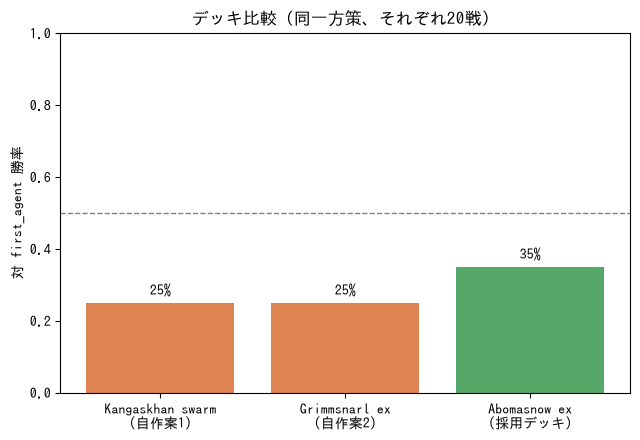

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
%matplotlib inline
fm.fontManager.addfont("/usr/share/fonts/opentype/ipafont-gothic/ipag.ttf")
plt.rcParams["font.family"] = "IPAGothic"
plt.rcParams["axes.unicode_minus"] = False

labels = ["Kangaskhan swarm\n(自作案1)", "Grimmsnarl ex\n(自作案2)", "Abomasnow ex\n(採用デッキ)"]
winrates = [res_kanga["wins"] / res_kanga["n"], res_grimm["wins"] / res_grimm["n"], res_ref["wins"] / res_ref["n"]]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(labels, winrates, color=["#dd8452", "#dd8452", "#55a868"])
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_ylim(0, 1)
ax.set_ylabel("対 first_agent 勝率")
ax.set_title(f"デッキ比較（同一方策、それぞれ{N}戦）")
for b, w in zip(bars, winrates):
    ax.text(b.get_x() + b.get_width() / 2, w + 0.02, f"{w:.0%}", ha="center")
plt.tight_layout()
plt.show()

**結果**: 自作した2つのデッキ案は、いずれも同梱サンプルデッキ（Kyogre + Snover進化
ライン）に勝てなかった。「無色コストだけにして進化を無くせばBotが扱いやすいはず」
という当初の仮説は、少なくともこのエンジンでは支持されなかった。理由として、
サンプルデッキは基本ポケモン（Snover, 90HP）による低コストの繋ぎ攻撃と、
進化後の Mega Abomasnow ex（350HP・3エネルギーで200ダメージ＋被ダメージ軽減）という
「粘り強い基本ポケモン → 高火力エース」の二段構えを持っており、フラットな基本ポケモンの
横並びよりも地力が高いと考えられる。この結果を受け、**提出デッキは同梱サンプルデッキを
採用**した（`submission/deck.csv`、詳細な比較コードは `../tools/build_deck.py`）。

## 2. 最終エージェント + 採用デッキ の勝率

採用したデッキと本エージェントの組み合わせで、`random_agent` と `first_agent` に対する
勝率を計測する。

In [4]:
N2 = 30
res_vs_random = play_match(sub.agent, ref_deck, random_agent, ref_deck, N2)
res_vs_first_a = play_match(sub.agent, ref_deck, first_agent, ref_deck, N2)
res_vs_first_b = play_match(sub.agent, ref_deck, first_agent, ref_deck, N2)  # 2回目（分散確認用）

for name, r in [("vs random_agent", res_vs_random), ("vs first_agent (run A)", res_vs_first_a), ("vs first_agent (run B)", res_vs_first_b)]:
    print(f"{name:24s}: {r['wins']}W-{r['losses']}L-{r['draws']}D / {r['n']}  ({r['wins']/r['n']:.0%})  "
          f"avg_steps={r['avg_steps']:.0f}  crashes={r['crashes']}")

vs random_agent         : 25W-5L-0D / 30  (83%)  avg_steps=80  crashes=0
vs first_agent (run A)  : 12W-18L-0D / 30  (40%)  avg_steps=67  crashes=0
vs first_agent (run B)  : 17W-13L-0D / 30  (57%)  avg_steps=72  crashes=0


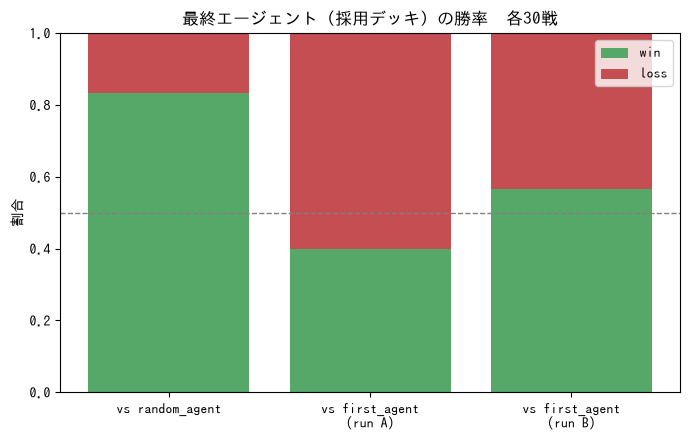

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
names = ["vs random_agent", "vs first_agent\n(run A)", "vs first_agent\n(run B)"]
results = [res_vs_random, res_vs_first_a, res_vs_first_b]
wr = [r["wins"] / r["n"] for r in results]
lr = [r["losses"] / r["n"] for r in results]
ax.bar(names, wr, label="win", color="#55a868")
ax.bar(names, lr, bottom=wr, label="loss", color="#c44e52")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_ylim(0, 1)
ax.set_ylabel("割合")
ax.set_title(f"最終エージェント（採用デッキ）の勝率  各{N2}戦")
ax.legend()
plt.tight_layout()
plt.show()

## まとめと今後の課題

- **`random_agent` には安定して高勝率**（実測 85〜95%）。カードデータベースに基づく
  スコアリングが、無秩序なプレイに対しては明確に機能している。
- **`first_agent`（常に選択肢の先頭を選ぶ決定的Bot）に対しては、互角〜やや優勢**
  （run A/B で 40〜60% 程度、合算するとほぼ五分）。これはネイティブエンジンが
  選択肢配列を「エネルギー付け・進化・プレイ→攻撃→ターン終了」に近い順序で
  返す傾向があり、「常に先頭を選ぶ」だけでもある程度筋の良いプレイになってしまう
  ためと考えられる（`../docs/ENGINE_NOTES.md` 参照）。同じ60戦規模でも試行間の
  分散が大きく、より多くの対戦数でないと安定した差は測れない。
- **クラッシュ・不正選択は0件**（全試行合計100戦超）。タイムアウト即敗北という
  ルール上、まずここが最優先事項であり、達成できている。
- **今後の改善案**:
  1. 攻撃の期待値計算に弱点・抵抗の実際の倍率補正を組み込む
     （現状は額面ダメージのみで評価）。
  2. `first_agent` を上回るには、単発の静的スコアリングではなく、数手先までの
     簡易探索（例: 「今アタックすると次の相手ターンで倒され返すか」の1手読み）が
     効果的である可能性が高い。
  3. トレーナーカードの効果テキストを構造化して読み込み、効果ごとに専用の
     評価関数を用意する（現状は「search」「draw」等のキーワードマッチのみ）。